1. Import Libraries

In [94]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

 2. Load Dataset

In [95]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


3. Data Understanding

In [96]:
df.shape

(2640, 12)

In [97]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 247.6 KB


In [98]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [99]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='str')

 4. Data Cleaning

In [100]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Observation:
No missing values were found in the dataset.



In [101]:
df.duplicated().sum()

np.int64(0)

Observation:
No duplicate records were found in the dataset.

In [102]:
df.dtypes

Year                      int64
Month                     int64
Region                      str
Model                       str
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type                 str
Charging_Stations         int64
dtype: object

5.Exploratory Data Analysis (EDA)

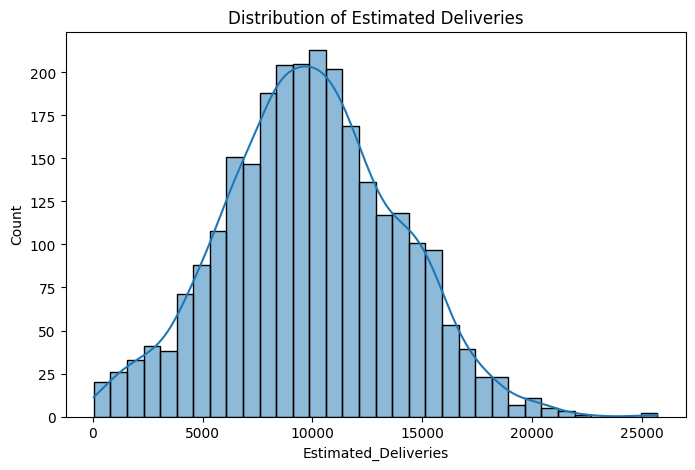

In [103]:
plt.figure(figsize=(8,5))

sns.histplot(df['Estimated_Deliveries'], kde=True)

plt.title("Distribution of Estimated Deliveries")

plt.show()

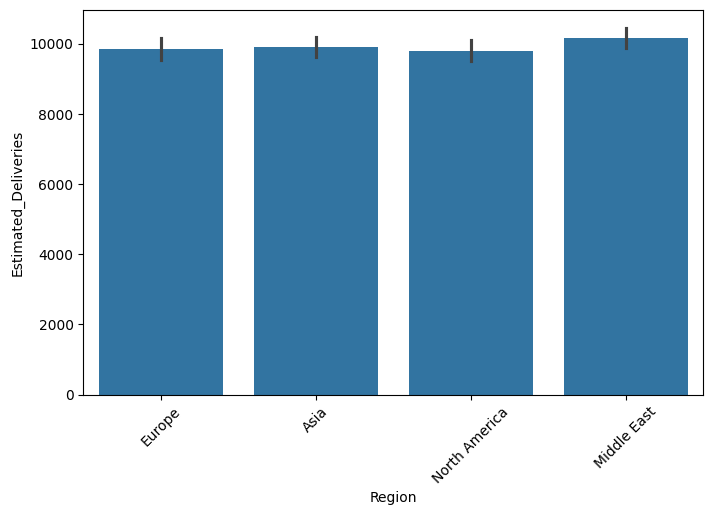

In [104]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Region',
    y='Estimated_Deliveries'
)

plt.xticks(rotation=45)

plt.show()

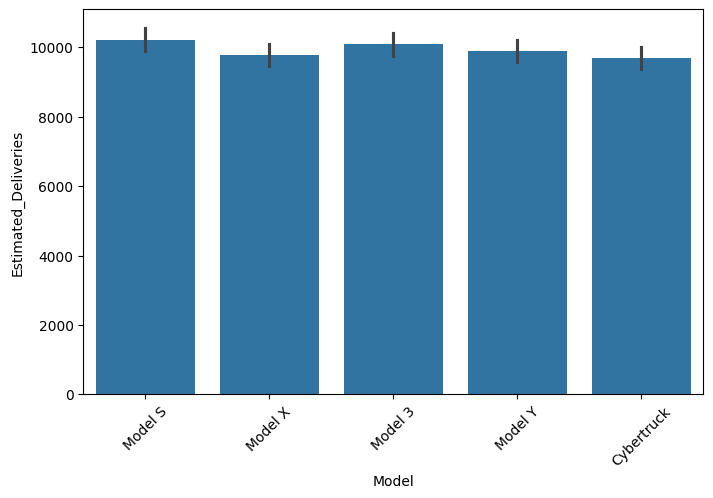

In [105]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Model',
    y='Estimated_Deliveries'
)

plt.xticks(rotation=45)

plt.show()

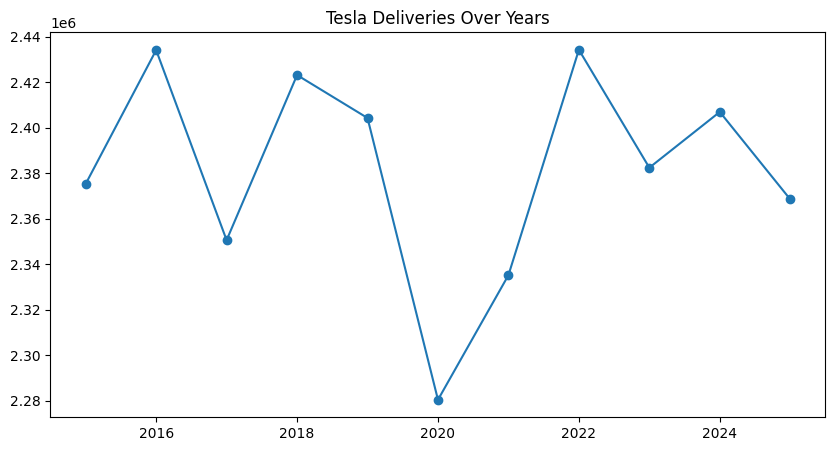

In [106]:
yearly = df.groupby("Year")["Estimated_Deliveries"].sum()

plt.figure(figsize=(10,5))

plt.plot(yearly.index, yearly.values, marker='o')

plt.title("Tesla Deliveries Over Years")

plt.show()

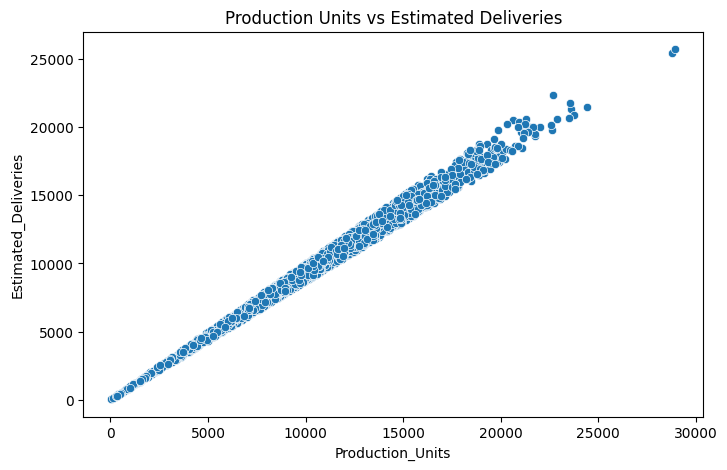

In [107]:

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Production_Units',
    y='Estimated_Deliveries'
)

plt.title("Production Units vs Estimated Deliveries")

plt.show()

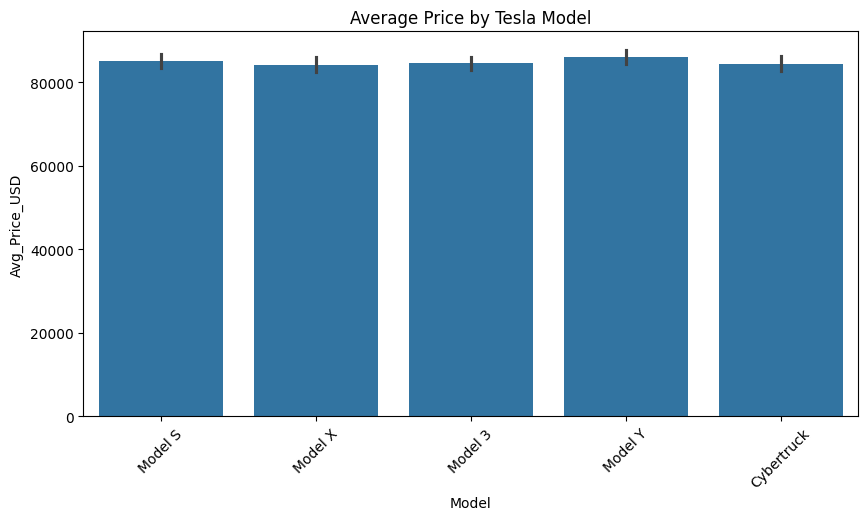

In [108]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x='Model',
    y='Avg_Price_USD'
)

plt.xticks(rotation=45)

plt.title("Average Price by Tesla Model")

plt.show()

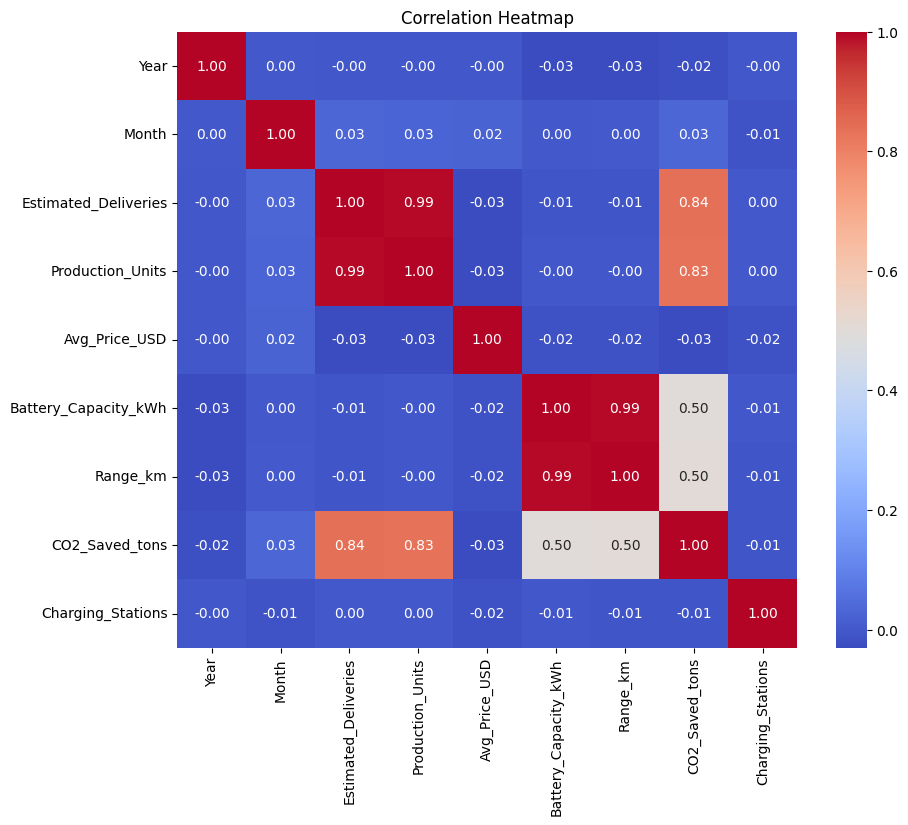

In [109]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

 Key Insights from EDA:
- The dataset contains clean and complete records.
- Tesla deliveries show noticeable variation across regions and models.
- Deliveries exhibit an overall trend across the years.
- Production Units appear to be positively related to Estimated Deliveries.
- Correlation analysis helps identify important predictors for regression modeling.

 6. Feature Engineering

In [110]:
df['Date'] = pd.to_datetime(dict(year=df['Year'], month=df['Month'], day=1))

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01


In [111]:
df['Quarter'] = df['Date'].dt.quarter

df[['Date','Quarter']].head()

,Date,Quarter
0,2023-05-01,2
1,2015-02-01,1
2,2019-01-01,1
3,2021-02-01,1
4,2016-12-01,4


In [112]:
df = df.sort_values('Date').reset_index(drop=True)

In [113]:
df['Previous_Month_Deliveries'] = df['Estimated_Deliveries'].shift(1)

In [114]:
df['Rolling_Mean_3'] = df['Estimated_Deliveries'].rolling(window=3).mean()

In [115]:
df = df.dropna().reset_index(drop=True)

In [116]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = ['Region', 'Model', 'Source_Type']

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Previous_Month_Deliveries,Rolling_Mean_3
0,2015,1,2,0,8803,9344,102888.58,60,336,443.67,1,3923,2015-01-01,1,11446.0,10898.333333
1,2015,1,3,0,6367,6802,104962.32,82,459,438.37,0,9170,2015-01-01,1,8803.0,8872.000000
2,2015,1,0,1,8795,9165,87988.73,82,456,601.58,2,12626,2015-01-01,1,6367.0,7988.333333
3,2015,1,1,0,2161,2465,112637.91,120,695,225.28,0,14062,2015-01-01,1,8795.0,5774.333333
4,2015,1,3,2,11986,13302,91906.09,82,457,821.64,0,4871,2015-01-01,1,2161.0,7647.333333


7. Data Preprocessing

In [117]:
X = df.drop(columns=['Estimated_Deliveries', 'Date'])
y = df['Estimated_Deliveries']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (2638, 14)
Target Shape: (2638,)


In [118]:
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print(X_train.shape, X_test.shape)

(2110, 14) (528, 14)


In [119]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

8. Regression Modeling

In [120]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    predictions = model.predict(X_test)

    # Calculate evaluation metrics
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    # Display results
    print("=" * 50)
    print(model_name)
    print("=" * 50)
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R² Score : {r2:.4f}")

    return mae, rmse, r2, predictions

Linear Regression

In [121]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_mae, linear_rmse, linear_r2, linear_predictions = evaluate_model(
    linear_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    "Linear Regression"
)

Linear Regression
MAE  : 323.70
RMSE : 392.52
R² Score : 0.9884


Ridge Regression

In [122]:
from sklearn.linear_model import Ridge

ridge_model = Ridge()

ridge_mae, ridge_rmse, ridge_r2, ridge_predictions = evaluate_model(
    ridge_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    "Ridge Regression"
)

Ridge Regression
MAE  : 323.29
RMSE : 392.34
R² Score : 0.9884


Lasso Regression

In [123]:
from sklearn.linear_model import Lasso

lasso_model = Lasso()

lasso_mae, lasso_rmse, lasso_r2, lasso_predictions = evaluate_model(
    lasso_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    "Lasso Regression"
)

Lasso Regression
MAE  : 323.13
RMSE : 392.06
R² Score : 0.9884


9.Model Comparison

In [124]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "MAE": [
        linear_mae,
        ridge_mae,
        lasso_mae
    ],
    "RMSE": [
        linear_rmse,
        ridge_rmse,
        lasso_rmse
    ],
    "R² Score": [
        linear_r2,
        ridge_r2,
        lasso_r2
    ]
})

comparison = comparison.sort_values(by="R² Score", ascending=False)

comparison

,Model,MAE,RMSE,R² Score
2,Lasso Regression,323.134699,392.059831,0.988439
1,Ridge Regression,323.294093,392.340046,0.988422
0,Linear Regression,323.699065,392.522322,0.988412


10. Hyperparameter Tuning

In [125]:
from sklearn.model_selection import GridSearchCV

Ridge Regression Tuning

In [126]:
ridge_params = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    estimator=Ridge(),
    param_grid=ridge_params,
    cv=5,
    scoring='r2'
)

ridge_grid.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexes are also d

In [127]:
print("Best Parameters:", ridge_grid.best_params_)
print("Best Cross Validation Score:", ridge_grid.best_score_)

Best Parameters: {'alpha': 0.1}
Best Cross Validation Score: 0.9906688467814029


In [128]:
best_ridge = ridge_grid.best_estimator_

best_ridge_mae, best_ridge_rmse, best_ridge_r2, best_ridge_predictions = evaluate_model(
    best_ridge,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    "Tuned Ridge Regression"
)

Tuned Ridge Regression
MAE  : 323.66
RMSE : 392.50
R² Score : 0.9884


Lasso Regression Tuning

In [129]:
lasso_params = {
    'alpha': [0.001, 0.01, 0.1, 1, 10]
}
lasso_grid = GridSearchCV(
    estimator=Lasso(),
    param_grid=lasso_params,
    cv=5,
    scoring='r2'
)

lasso_grid.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Lasso()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexes are also

In [130]:
print("Best Parameters:", lasso_grid.best_params_)
print("Best Cross Validation Score:", lasso_grid.best_score_)

Best Parameters: {'alpha': 1}
Best Cross Validation Score: 0.990675274462447


In [131]:
best_lasso = lasso_grid.best_estimator_

best_lasso_mae, best_lasso_rmse, best_lasso_r2, best_lasso_predictions = evaluate_model(
    best_lasso,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    "Tuned Lasso Regression"
)

Tuned Lasso Regression
MAE  : 323.13
RMSE : 392.06
R² Score : 0.9884


comparison

In [132]:
final_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Tuned Ridge Regression",
        "Tuned Lasso Regression"
    ],
    "MAE": [
        linear_mae,
        ridge_mae,
        lasso_mae,
        best_ridge_mae,
        best_lasso_mae
    ],
    "RMSE": [
        linear_rmse,
        ridge_rmse,
        lasso_rmse,
        best_ridge_rmse,
        best_lasso_rmse
    ],
    "R² Score": [
        linear_r2,
        ridge_r2,
        lasso_r2,
        best_ridge_r2,
        best_lasso_r2
    ]
})

final_comparison = final_comparison.sort_values(
    by="R² Score",
    ascending=False
)

final_comparison

,Model,MAE,RMSE,R² Score
2,Lasso Regression,323.134699,392.059831,0.988439
4,Tuned Lasso Regression,323.134699,392.059831,0.988439
1,Ridge Regression,323.294093,392.340046,0.988422
3,Tuned Ridge Regression,323.656808,392.501266,0.988413
0,Linear Regression,323.699065,392.522322,0.988412


11. Actual vs Predicted Values

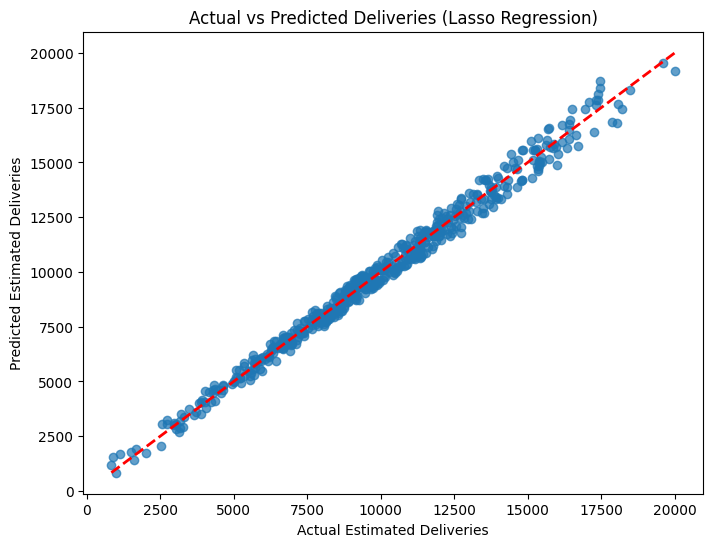

In [133]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, lasso_predictions, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--',
    linewidth=2
)

plt.xlabel("Actual Estimated Deliveries")
plt.ylabel("Predicted Estimated Deliveries")
plt.title("Actual vs Predicted Deliveries (Lasso Regression)")

plt.show()

12. Time Series Forecasting

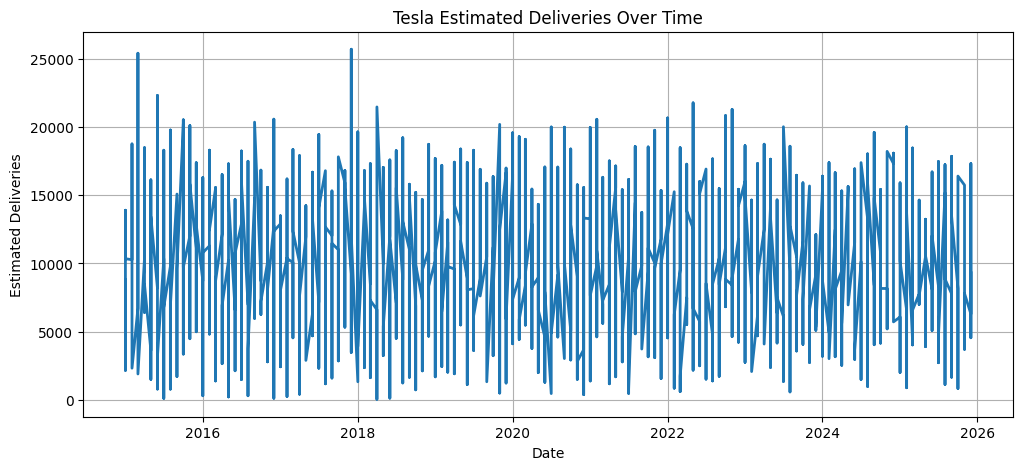

In [134]:
plt.figure(figsize=(12,5))

plt.plot(
    df["Date"],
    df["Estimated_Deliveries"],
    linewidth=2
)

plt.title("Tesla Estimated Deliveries Over Time")

plt.xlabel("Date")

plt.ylabel("Estimated Deliveries")

plt.grid(True)

plt.show()

In [135]:
forecast_df = pd.DataFrame({
    "Date": df.iloc[split:]["Date"],
    "Actual": y_test.values,
    "Predicted": lasso_predictions
})

forecast_df.head()

,Date,Actual,Predicted
2110,2023-10-01,8910,9291.714043
2111,2023-10-01,10819,10618.919590
2112,2023-10-01,5341,5713.420761
2113,2023-10-01,8195,8080.759978
2114,2023-10-01,8179,8432.128697


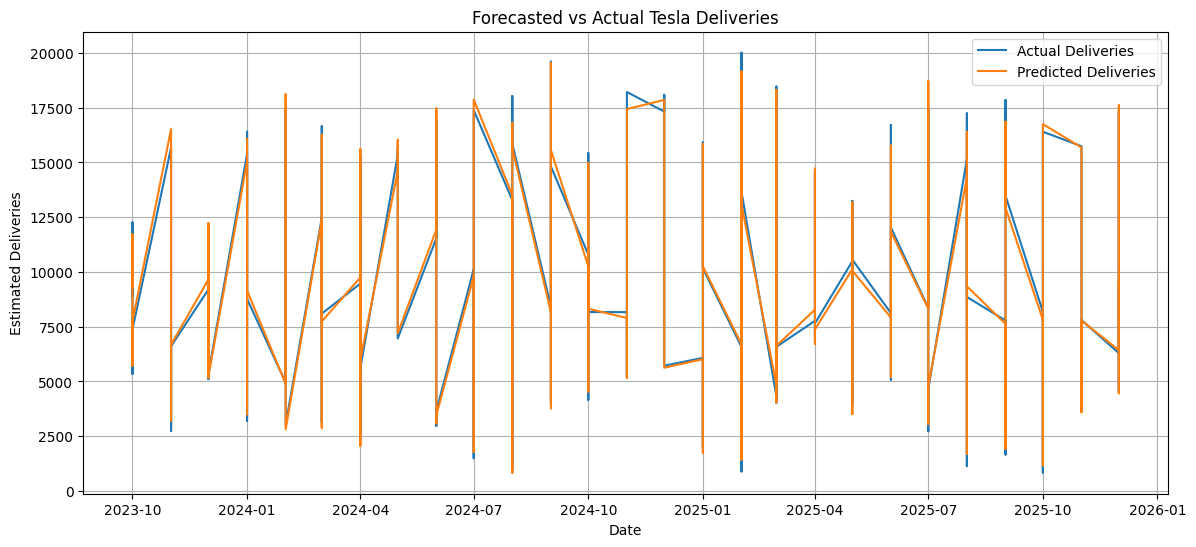

In [136]:
plt.figure(figsize=(14,6))

plt.plot(
    forecast_df["Date"],
    forecast_df["Actual"],
    label="Actual Deliveries"
)

plt.plot(
    forecast_df["Date"],
    forecast_df["Predicted"],
    label="Predicted Deliveries"
)

plt.title("Forecasted vs Actual Tesla Deliveries")

plt.xlabel("Date")

plt.ylabel("Estimated Deliveries")

plt.legend()

plt.grid(True)

plt.show()

 13. Conclusion

An end-to-end machine learning pipeline was successfully developed to predict Tesla estimated deliveries.

Key tasks completed in this project include:

- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Feature Scaling
- Chronological Train-Test Split
- Regression Modeling
- Hyperparameter Tuning using GridSearchCV
- Model Evaluation
- Time Series Forecasting

Among the evaluated models, **Lasso Regression** achieved the highest R² score on the test dataset, making it the best-performing model for this project. Hyperparameter tuning confirmed that the default Lasso configuration already provided excellent performance, while Ridge Regression showed comparable results.

Overall, the developed pipeline demonstrates a complete workflow for solving a regression-based forecasting problem using machine learning techniques.